Step 1: Mounting Drive

In [1]:
from google.colab import drive
import pandas as pd

# Mount your Google Drive
drive.mount('/content/drive')



Mounted at /content/drive


Step 2 : Load the data and checking the structure of Dataset

In [2]:
# Load your CSV file (adjust the path to match where it’s stored in Drive)
file_path = '/content/drive/MyDrive/CSV Files/Reviews.csv'   # ← change this if needed
df = pd.read_csv(file_path)

# Check the structure
print(df.head())
print(df.columns)


   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3                       3      2  1307923200   
4                     0                       0      5  1350777600   

                 Summary                                               Text  
0  Good Quality Dog Food  I have bought several of the Vitality canned d...  
1 

Step 4 : Importing necessary libraries

In [3]:
# Step 2: Import required libraries
import pandas as pd
from transformers import pipeline
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer


Step 5: preparing the text column

In [4]:
# Rename column to 'Post' for consistency
df.rename(columns={'Text': 'Post'}, inplace=True)

# Ensure all values are strings and fill missing entries
df['Post'] = df['Post'].astype(str).fillna("")

# Optionally, select only first 150 posts
df_subset = df.head(150).copy()

# Convert 'Post' column to list
texts = df_subset['Post'].tolist()



Step 6: Intialize Transformers Pipelines

In [5]:
# Zero-shot classification for Label
labeler = pipeline("zero-shot-classification", model="facebook/bart-large-mnli")

# Sentiment analysis
sentiment_analyzer = pipeline("sentiment-analysis")

# Define candidate labels (customize as needed)
candidate_labels = ["product quality", "delivery", "price", "customer service", "usability", "food", "packaging"]


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Step 7: Run Labeling and Sentiment Analysis

In [6]:
from tqdm import tqdm

# Prepare storage lists
labels, label_scores, sentiments, sentiment_scores = [], [], [], []

# Process in small batches for efficiency
batch_size = 8

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i+batch_size]

    # ---- Zero-shot classification ----
    # Truncate texts to 512 tokens (model limit)
    truncated_batch = [t[:1000] for t in batch]  # ~512 tokens ≈ 1000 characters
    label_results = labeler(truncated_batch, candidate_labels, truncation=True)

    for r in label_results:
        labels.append(r['labels'][0])
        label_scores.append(r['scores'][0])

    # ---- Sentiment analysis ----
    sentiment_results = sentiment_analyzer(truncated_batch, truncation=True)
    for r in sentiment_results:
        sentiments.append(r['label'])
        sentiment_scores.append(r['score'])



100%|██████████| 19/19 [00:35<00:00,  1.89s/it]


Step 6: Add Results to DataFrame

In [7]:
# Add new columns to dataframe
df_subset['Label'] = labels
df_subset['Score_Label'] = label_scores
df_subset['Sentiment'] = sentiments
df_subset['Score_Sentiment'] = sentiment_scores


Step 7: Cluster Posts Using TF-IDF and KMeans

In [8]:
# Convert posts to TF-IDF vectors
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df_subset['Post'])

# Apply KMeans clustering (choose number of clusters, e.g., 5)
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df_subset['Cluster'] = kmeans.fit_predict(X)


Step 8: Save Final DataFrame

In [9]:
# Save results back to Google Drive
output_path = '/content/drive/MyDrive/reviews_with_analysis.csv'
df_subset.to_csv(output_path, index=False)

print("✅ Completed! File saved at:", output_path)
df_subset.head(10)


✅ Completed! File saved at: /content/drive/MyDrive/reviews_with_analysis.csv


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Post,Label,Score_Label,Sentiment,Score_Sentiment,Cluster
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...,product quality,0.658408,POSITIVE,0.998385,3
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,delivery,0.473304,NEGATIVE,0.999525,0
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...,food,0.437714,POSITIVE,0.999765,1
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...,product quality,0.308669,POSITIVE,0.999153,4
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...,price,0.424139,POSITIVE,0.998708,3
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...,food,0.482214,POSITIVE,0.999255,3
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...,product quality,0.355473,POSITIVE,0.999364,0
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...,product quality,0.532266,POSITIVE,0.999883,1
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...,food,0.745952,POSITIVE,0.998517,2
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...,food,0.457677,POSITIVE,0.999456,3


In [15]:
from sklearn.cluster import KMeans
from transformers import pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv('/content/drive/MyDrive/CSV Files/Reviews.csv')

texts = df["Text"].dropna().tolist()   # text column

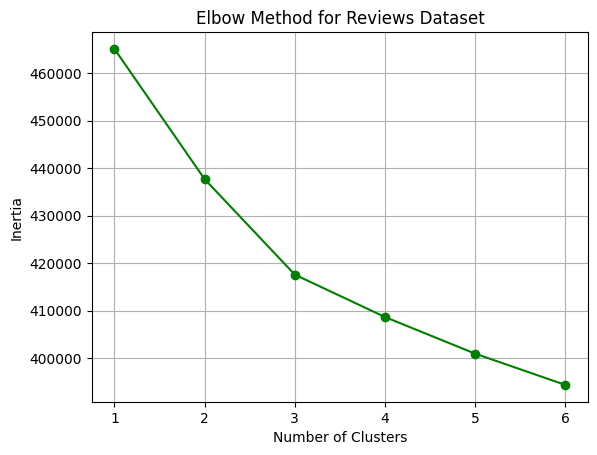

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# -----------------------------
# Elbow Method
# -----------------------------
inertia_list = []

for k in range(1, 7):
    kmn = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmn.fit(embeddings)
    inertia_list.append(kmn.inertia_)

# -----------------------------
# Plot Elbow Graph
# -----------------------------
plt.plot(range(1, 7), inertia_list, 'o-', color='green')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Reviews Dataset")
plt.grid(True)
plt.show()